In [171]:
import glob as glob
import pandas as pd

# load in a envelope
acoustics = '../../TS_acoustics'
envelopes = glob.glob(acoustics + '/env_*')
print(envelopes)
example = 17
envtest = pd.read_csv(envelopes[example])
envtest.head()

['../../TS_acoustics\\env_103_203_12_1_20250113_152455_doughnut_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_13_1_20250113_152513_spinach_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_14_1_20250113_152536_balloon_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_15_1_20250113_152557_bacon_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_16_1_20250113_152613_chlorine_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_17_1_20250113_152643_leather_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_18_1_20250113_152657_pillow_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_19_1_20250113_152712_traffic_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_20_1_20250113_152735_bitter_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_21_1_20250113_152824_tiger_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_23_1_20250113_152946_trumpet_ground.wav_norm.csv', '../../TS_acoustics\\env_103_203_24_1_20250113_152957_pasta_ground.wav_norm.csv', '../../

,time,audio,envelope,filename,envelope_norm,envelope_change
0,0.0,0.000000,0.000016,103_203_30_1_20250113_153310_exam_ground.wav,0.035306,-0.000011
1,2.0,0.000000,0.000018,103_203_30_1_20250113_153310_exam_ground.wav,0.035344,0.000072
2,4.0,0.000003,0.000020,103_203_30_1_20250113_153310_exam_ground.wav,0.035383,0.000153
3,6.0,-0.000058,0.000022,103_203_30_1_20250113_153310_exam_ground.wav,0.035422,0.000230
4,8.0,0.000162,0.000024,103_203_30_1_20250113_153310_exam_ground.wav,0.035462,0.000303


<Axes: xlabel='t'>

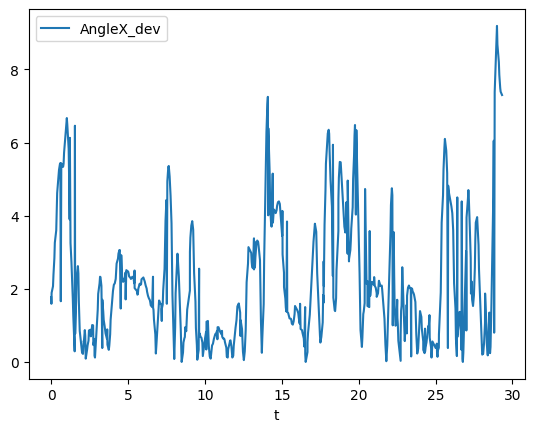

In [172]:
import numpy as np

g = gyrotest.copy()
g['t'] = (pd.to_datetime(g['time']) - pd.to_datetime(g['time']).iloc[0]).dt.total_seconds()
g = g.sort_values('t').reset_index(drop=True)      # MUST be time-ordered before unwrap

ang = g['AngleX(°)'].to_numpy()

# 1. unwrap: removes the ±180 jumps (np.unwrap works in radians)
ang_u = np.degrees(np.unwrap(np.radians(ang)))

# 2. recentre on resting posture (median = the upright baseline), then absolute deviation
ang_dev = np.abs(ang_u - np.median(ang_u))         # |lean away from centre|

g['AngleX_dev'] = ang_dev
g.plot(x='t', y='AngleX_dev')                       # should be smooth, no cliffs

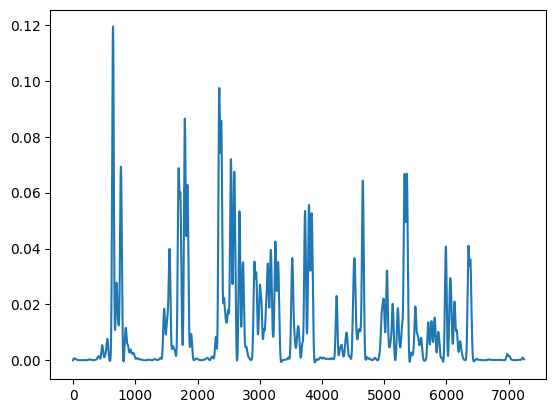

In [173]:
# plot  a single envelope
import matplotlib.pyplot as plt

# timeseries envelope
plt.plot(envtest['envelope_change'])

In [174]:
import numpy as np
import pandas as pd
from scipy.ndimage import uniform_filter1d

FS_ENV = 500.0

env = envtest['envelope'].to_numpy()
t_env = envtest['time'].to_numpy().astype(float)
if np.median(np.diff(t_env)) > 0.5:            # ms -> s
    t_env = t_env / 1000.0

# --- gyro: sort FIRST (before unwrap/smooth) ---
g = gyrotest.copy()
g['t'] = (pd.to_datetime(g['time']) - pd.to_datetime(g['time']).iloc[0]).dt.total_seconds()
g = g.sort_values('t').reset_index(drop=True)
t_gyr = g['t'].to_numpy()

# predictor A: angular-speed magnitude (signed -> |.|)
asx_col = next(c for c in g.columns if c.startswith('AsX'))
speed = g[asx_col].to_numpy()

# predictor B: angle DEVIATION from upright (unwrap FIRST, then recentre)
ang_col = next(c for c in g.columns if c.startswith('AngleX'))
ang_u   = np.degrees(np.unwrap(np.radians(g[ang_col].to_numpy())))   # kill ±180 cliffs
ang_dev = np.abs(ang_u - np.median(ang_u))                           # |lean from centre|

# clip to overlap once
lo, hi = max(t_env[0], t_gyr[0]), min(t_env[-1], t_gyr[-1])
m = (t_env >= lo) & (t_env <= hi)
t, env_c = t_env[m], env[m]

# interpolate both onto the envelope grid, then smooth on the uniform grid
SMOOTH_S = 0.5
w = max(1, int(SMOOTH_S * FS_ENV))
ml_c    = uniform_filter1d(np.abs(np.interp(t, t_gyr, speed)),   w)  # sway speed magnitude
angdev_c = uniform_filter1d(       np.interp(t, t_gyr, ang_dev),  w)  # postural lean

print(f"overlap {lo:.2f}–{hi:.2f}s, {m.sum()} samples | "
      f"lean range {angdev_c.min():.1f}–{angdev_c.max():.1f}°")

overlap 0.00–14.49s, 7245 samples | lean range 0.3–5.9°


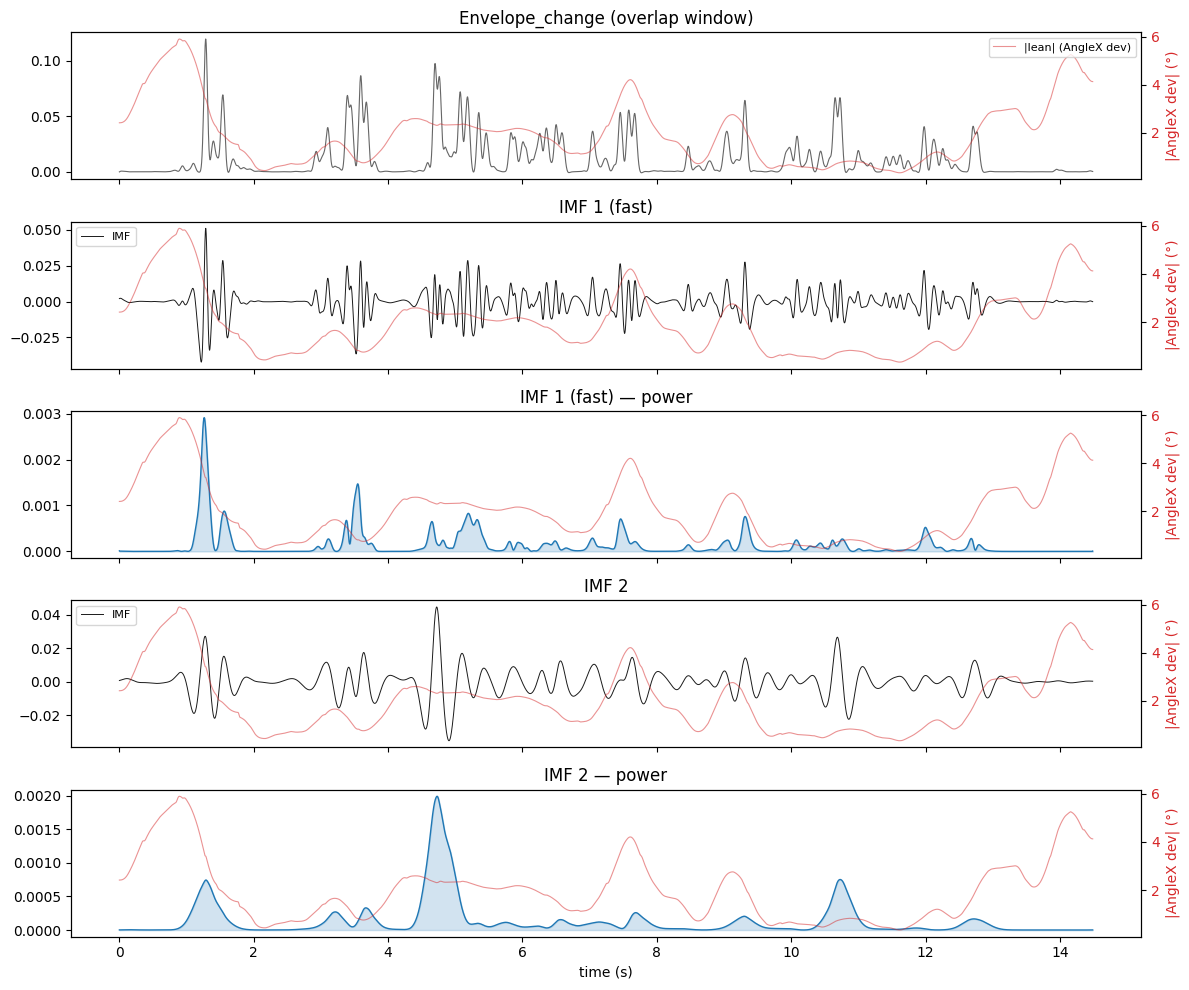

In [175]:
import emd
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

sig = envtest['envelope_change'].to_numpy()[m]
imf_env = emd.sift.mask_sift(sig, max_imfs=2)

amp = np.abs(hilbert(imf_env, axis=0))
pwr = amp ** 2

fig, ax = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

def overlay_lean(a, show_label=False):
    ab = a.twinx()
    ab.plot(t, angdev_c, color='C3', lw=0.8, alpha=0.5, label='|lean| (AngleX dev)')
    ab.set_ylabel('|AngleX dev| (°)', color='C3')
    ab.tick_params(axis='y', labelcolor='C3')
    if show_label:
        ab.legend(loc='upper right', fontsize=8)
    return ab

ax[0].plot(t, sig, color='0.4', lw=0.8)
ax[0].set_title('Envelope_change (overlap window)')
overlay_lean(ax[0], show_label=True)

for k, name in [(0, 'IMF 1 (fast)'), (1, 'IMF 2')]:
    a_imf = ax[1 + 2 * k]
    a_imf.plot(t, imf_env[:, k], color='0.1', lw=0.7, label='IMF')
    a_imf.set_title(name); a_imf.legend(loc='upper left', fontsize=8)
    overlay_lean(a_imf)

    a_pwr = ax[2 + 2 * k]
    a_pwr.plot(t, pwr[:, k], 'C0', lw=1.0, label='power')
    a_pwr.fill_between(t, pwr[:, k], color='C0', alpha=0.2)
    a_pwr.set_title(f'{name} — power')
    overlay_lean(a_pwr)

ax[-1].set_xlabel('time (s)')
plt.tight_layout()

envelope IMF mean freqs (Hz): [6.64 2.68]
IMF 1 (~6.64 Hz):  rho = +0.254,  p_shift = 0.094
IMF 2 (~2.68 Hz):  rho = +0.401,  p_shift = 0.040


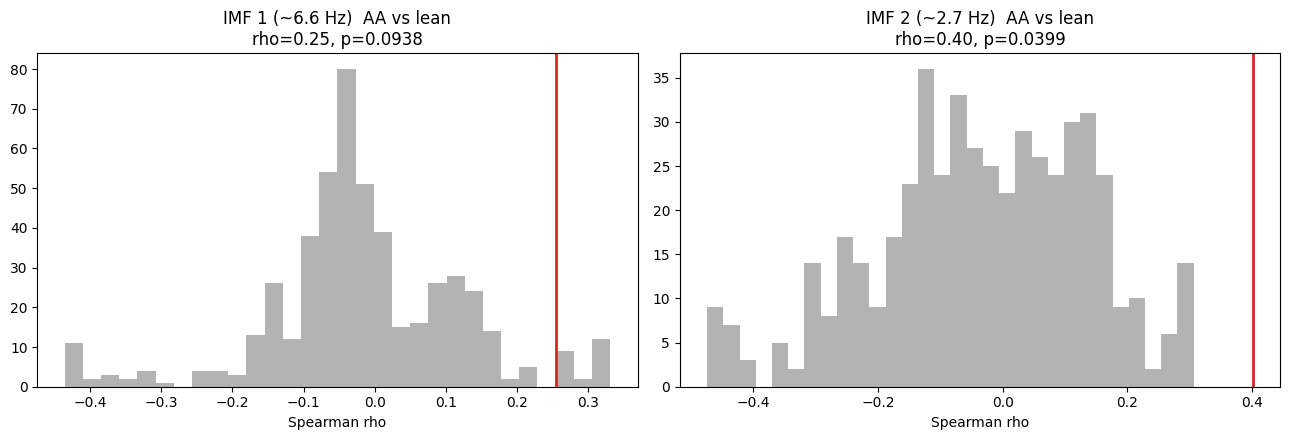

In [176]:
import emd
import numpy as np
from scipy.signal import hilbert
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# --- envelope IMFs + which band each one is ---
sig = envtest['envelope_change'].to_numpy()[m]
imf_env = emd.sift.mask_sift(sig, max_imfs=2)
_, IFe, IAe = emd.spectra.frequency_transform(imf_env, FS_ENV, 'hilbert')
mf_env = np.sum(IFe * IAe**2, 0) / np.sum(IAe**2, 0)
print("envelope IMF mean freqs (Hz):", np.round(mf_env, 2))

env_pwr = np.abs(hilbert(imf_env, axis=0)) ** 2          # (Nc, 2)

# --- AA test on each IMF vs postural LEAN (angle deviation) ---
edge = int(1.0 * FS_ENV)
y = angdev_c[edge:-edge]                                  # <-- lean, not speed
rng = np.random.default_rng(1); N_SURR = 500

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for k in range(2):
    x = env_pwr[edge:-edge, k]
    rho, _ = spearmanr(x, y)
    n = len(x)
    null = np.array([spearmanr(x, np.roll(y, rng.integers(n//20, n-n//20)))[0]
                     for _ in range(N_SURR)])
    p = (np.sum(np.abs(null) >= abs(rho)) + 1) / (N_SURR + 1)
    print(f"IMF {k+1} (~{mf_env[k]:.2f} Hz):  rho = {rho:+.3f},  p_shift = {p:.3f}")

    ax[k].hist(null, 30, color='0.7')
    ax[k].axvline(rho, color='C3', lw=2)
    ax[k].set_title(f'IMF {k+1} (~{mf_env[k]:.1f} Hz)  AA vs lean\nrho={rho:.2f}, p={p:.3g}')
    ax[k].set_xlabel('Spearman rho')
plt.tight_layout()